In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [12]:
import seaborn as sns

In [3]:
df = pd.read_csv("../data/processed/penn_state_processed_stats_2024_2025.csv")
df.head()

,Date,Opponent,Location,Result,Box Score Link,WMT Game ID,PSU Goals,PSU Shots on Goal,PSU Total Shot Attempts,PSU Faceoffs Won,...,Total Shots on Goal,Faceoff Differential,PSU Save %,Opponent Save %,Home Game,Venue_Type,Total Goals,Total Penalty Minutes,PSU Shooting %,Opponent Shooting %
0,Saturday Oct 5,Alaska,"Fairbanks, Alaska",W Win 4-3,https://gopsusports.com/boxscore/16818,5722151,4,33,65,30,...,62,5.26,0.897,0.879,0,Away,7,14,12.121212,10.344828
1,Sunday Oct 6,Alaska,"Fairbanks, Alaska",W Win 5-0,https://gopsusports.com/boxscore/16819,5722152,5,32,54,35,...,64,-1.40,1.000,0.844,0,Away,5,52,15.625000,0.000000
2,Saturday Oct 12,Quinnipiac,"Hamden, Conn.",L Loss 2-3,https://gopsusports.com/boxscore/16820,5722153,2,20,45,25,...,42,-1.96,0.864,0.900,0,Away,5,14,10.000000,13.636364
3,Friday Oct 25,St. Lawrence,"University Park, Pa. / Pegula Ice Arena",W Win 3-2,https://gopsusports.com/boxscore/16821,5722154,3,28,58,40,...,44,29.04,0.875,0.893,1,Home,5,29,10.714286,12.500000
4,Saturday Oct 26,St. Lawrence,"University Park, Pa. / Pegula Ice Arena",W Win 3-1,https://gopsusports.com/boxscore/16822,5722155,3,37,65,40,...,63,40.36,0.962,0.919,1,Home,4,16,8.108108,3.846154


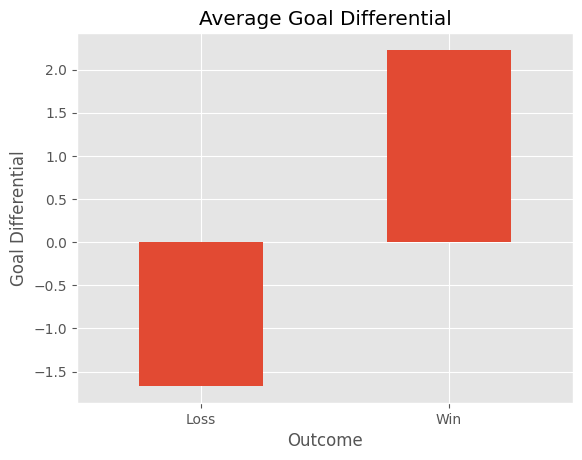

In [5]:
goal_diff = df.groupby("Win")["Goal Differential"].mean()

goal_diff.plot(kind="bar")

plt.title("Average Goal Differential")
plt.xlabel("Outcome")
plt.ylabel("Goal Differential")

plt.xticks([0,1], ["Loss", "Win"], rotation=0)

plt.show()

In [8]:
# Remove columns that shouldn't be compared
comparison = (
    df.drop(columns=["WMT Game ID", "Win", "Goal Differential"])
      .groupby(df["Win"])
      .mean(numeric_only=True)
      .T
)

comparison["Difference"] = comparison[1] - comparison[0]

comparison = comparison.sort_values(by = "Difference", ascending=False)

comparison.head(10)

Win,0,1,Difference
Shot Differential,-1.111111,3.045455,4.156566
PSU Shooting %,8.305484,12.449618,4.144134
Opponent Faceoff %,43.795556,47.367273,3.571717
Total Penalty Minutes,19.055556,22.318182,3.262626
Opponent Penalty Minutes,9.388889,12.545455,3.156566
PSU Blocks,13.777778,15.818182,2.040404
PSU Shots on Goal,32.111111,33.500000,1.388889
PSU Goals,2.777778,4.045455,1.267677
PSU Total Shot Attempts,60.222222,61.227273,1.005051
Opponent Saves,29.333333,29.454545,0.121212


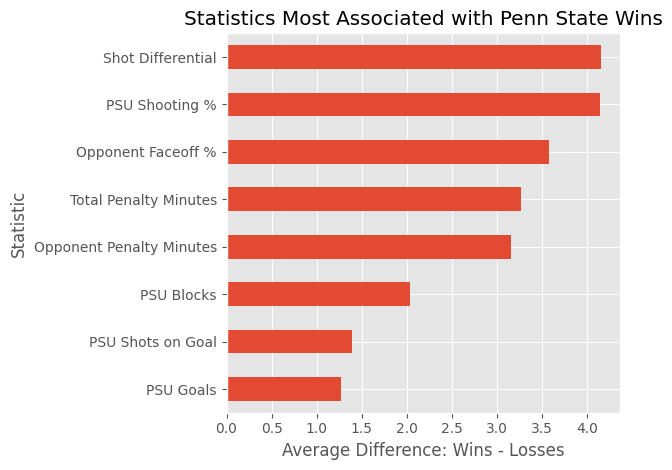

In [9]:
top_features = comparison.head(8)

top_features["Difference"].plot(kind = "barh")

plt.title("Statistics Most Associated with Penn State Wins")
plt.xlabel("Average Difference: Wins - Losses")
plt.ylabel("Statistic")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [10]:
selected_metrics  = [
    "Shot Differential",
    "Faceoff Differential",
    "PSU Shooting %",
    "PSU Save %",
    "PSU Blocks",
    "PSU Penalty Minutes"
]

win_loss_metrics = df.groupby("Win")[selected_metrics].mean().T

win_loss_metrics.columns = ["Loss", "Win"]

win_loss_metrics


,Loss,Win
Shot Differential,-1.111111,3.045455
Faceoff Differential,12.408889,5.265455
PSU Shooting %,8.305484,12.449618
PSU Save %,0.861944,0.938955
PSU Blocks,13.777778,15.818182
PSU Penalty Minutes,9.666667,9.772727


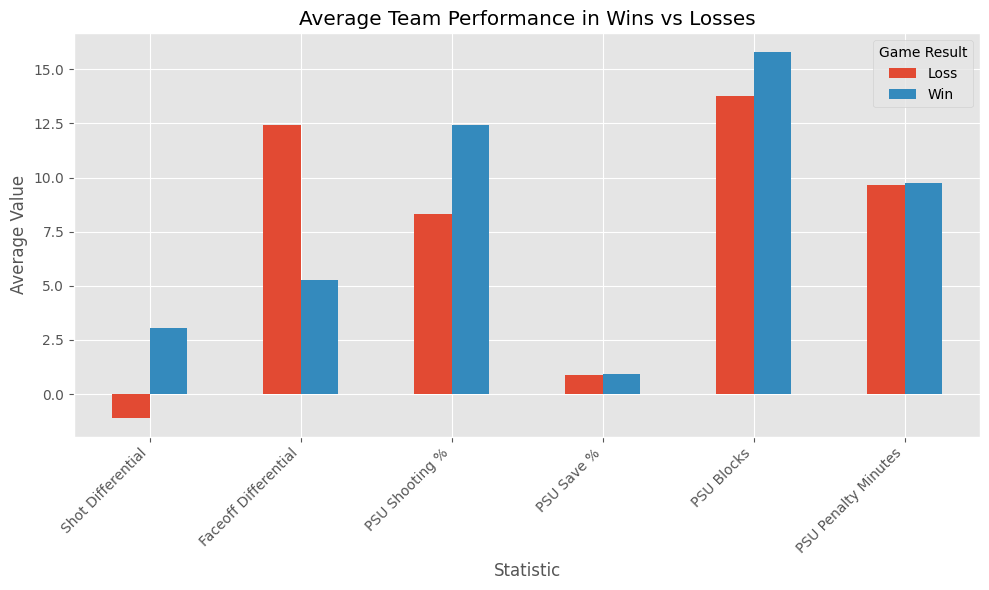

In [11]:
win_loss_metrics.plot(kind="bar", figsize=(10, 6))

plt.title("Average Team Performance in Wins vs Losses")
plt.xlabel("Statistic")
plt.ylabel("Average Value")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Game Result")

plt.tight_layout()
plt.show()


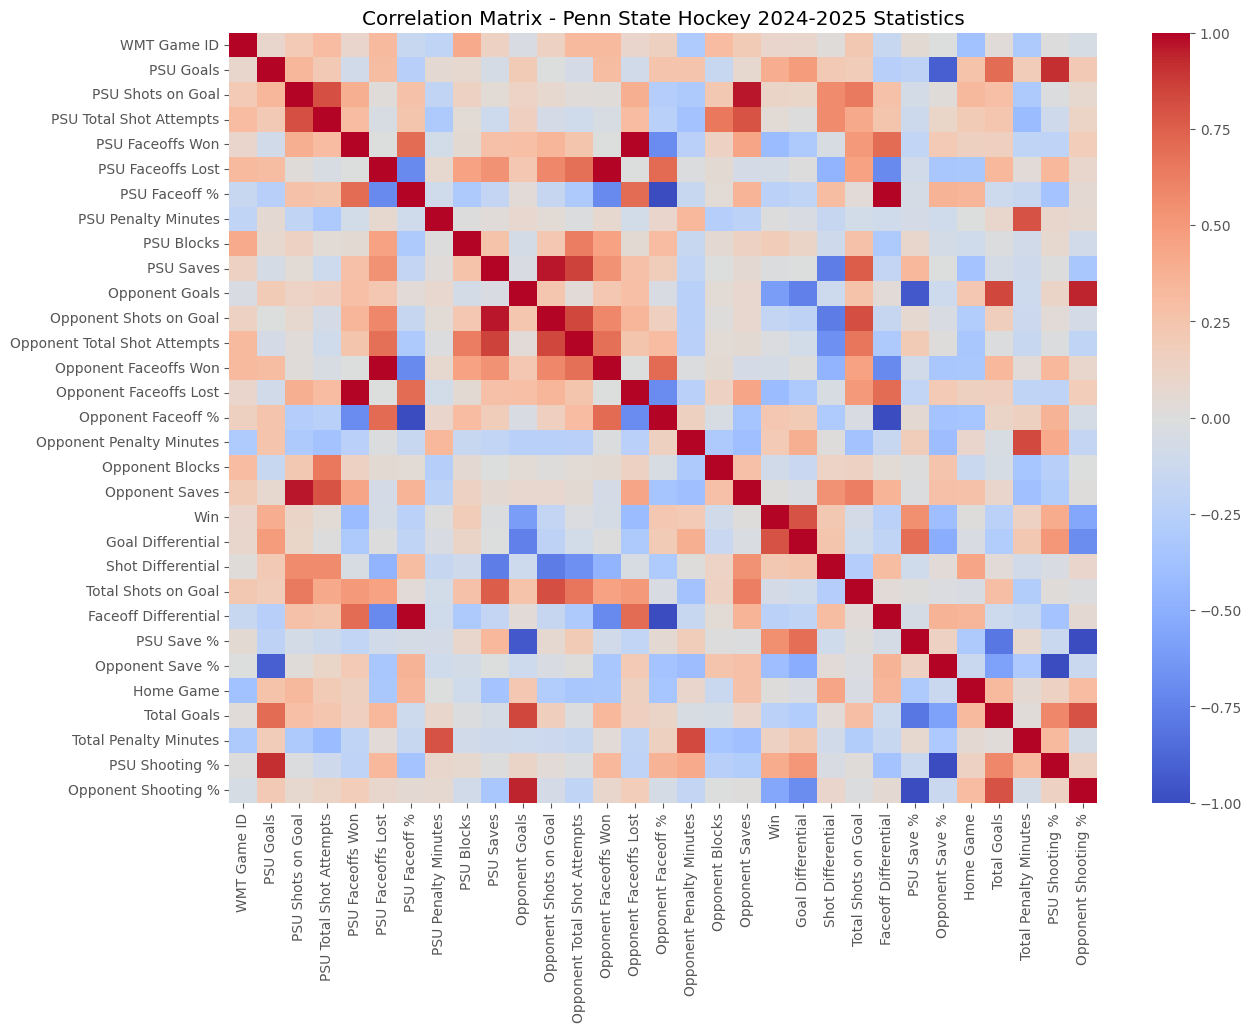

In [13]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr, 
    cmap = "coolwarm", 
    center = 0,
    annot = False
)

plt.title("Correlation Matrix - Penn State Hockey 2024-2025 Statistics")
plt.show()

In [20]:
win_corr = (corr["Win"].sort_values(ascending = False))

win_corr = win_corr.drop(labels=["Win", "Goal Differential", "WMT Game ID"],errors="ignore")

win_corr

PSU Save %                      0.553136
PSU Shooting %                  0.402380
PSU Goals                       0.391167
Opponent Faceoff %              0.226885
Shot Differential               0.219016
Opponent Penalty Minutes        0.205300
PSU Blocks                      0.187722
Total Penalty Minutes           0.134411
PSU Shots on Goal               0.116612
PSU Total Shot Attempts         0.044208
Opponent Saves                  0.010789
Home Game                       0.010101
PSU Penalty Minutes             0.007407
PSU Saves                      -0.009269
Opponent Total Shot Attempts   -0.018483
PSU Faceoffs Lost              -0.055409
Opponent Faceoffs Won          -0.055409
Total Shots on Goal            -0.067589
Opponent Blocks                -0.086322
Opponent Shots on Goal         -0.176352
PSU Faceoff %                  -0.226885
Faceoff Differential           -0.226885
Total Goals                    -0.230484
Opponent Save %                -0.401489
PSU Faceoffs Won